# Hacker News EDA + Clustering

APAN 5205 Team Project — Yike's part

This notebook does the EDA and clustering on the HN dataset. The output (`data/hn_with_clusters.csv`) will be used by the prediction notebook.

Sections:
- Section 1: EDA (score distribution, story types, time patterns, title length)
- Section 2: Text preprocessing + TF-IDF
- Section 3: KMeans clustering (elbow method to pick k)
- Section 4: Export the data with cluster labels

In [2]:
# basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

sns.set_theme(style='whitegrid')
%matplotlib inline

In [3]:
# load the cleaned dataset
df = pd.read_csv('data/hn_stories_clean.csv')
print('shape:', df.shape)
df.head()

shape: (14340, 20)


,objectID,title,url,author,score,num_comments,summary,summary_source,summary_length,created_at,date,year_month,day_of_week,hour,is_weekend,title_length,title_word_count,has_url,has_text,story_type
0,43213612,An update on Mozilla's terms of use for Firefox,https://blog.mozilla.org/en/products/firefox/u...,ReadCarlBarks,596,366,An update on Mozilla's terms of use for Firefox,no_meta_found,47,2025-02-28 23:59:35+00:00,2025-02-28,2025-02,4,23,0,47,9,1,0,external
1,43213583,It Was an Ambush,https://www.theatlantic.com/ideas/archive/2025...,dtquad,95,58,It Was an Ambush,no_meta_found,16,2025-02-28 23:56:35+00:00,2025-02-28,2025-02,4,23,0,16,4,1,0,external
2,43213563,Formation of organic glass from a human brain,https://www.nature.com/articles/s41598-025-888...,thund,14,3,Formation of organic glass from a human brain,no_meta_found,45,2025-02-28 23:54:24+00:00,2025-02-28,2025-02,4,23,0,45,8,1,0,research
3,43213530,Bloated Department of Defense spends more mone...,https://theintercept.com/2025/02/28/musk-doge-...,sea-gold,13,2,Bloated Department of Defense spends more mone...,no_meta_found,80,2025-02-28 23:52:16+00:00,2025-02-28,2025-02,4,23,0,80,12,1,0,external
4,43213504,European leaders show support for Zelenskiy af...,https://www.reuters.com/world/europe/european-...,sirolimus,49,13,European leaders show support for Zelenskiy af...,no_meta_found,61,2025-02-28 23:50:10+00:00,2025-02-28,2025-02,4,23,0,61,9,1,0,news_major


In [4]:
# quick look at the columns and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14340 entries, 0 to 14339
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   objectID          14340 non-null  int64
 1   title             14340 non-null  str  
 2   url               13605 non-null  str  
 3   author            14340 non-null  str  
 4   score             14340 non-null  int64
 5   num_comments      14340 non-null  int64
 6   summary           14340 non-null  str  
 7   summary_source    14340 non-null  str  
 8   summary_length    14340 non-null  int64
 9   created_at        14340 non-null  str  
 10  date              14340 non-null  str  
 11  year_month        14340 non-null  str  
 12  day_of_week       14340 non-null  int64
 13  hour              14340 non-null  int64
 14  is_weekend        14340 non-null  int64
 15  title_length      14340 non-null  int64
 16  title_word_count  14340 non-null  int64
 17  has_url           14340 non-null  int64
 1

In [5]:
# check for missing values
df.isnull().sum()

objectID              0
title                 0
url                 735
author                0
score                 0
num_comments          0
summary               0
summary_source        0
summary_length        0
created_at            0
date                  0
year_month            0
day_of_week           0
hour                  0
is_weekend            0
title_length          0
title_word_count      0
has_url               0
has_text              0
story_type            0
dtype: int64

In [6]:
df['score'].describe()

count    14340.000000
mean        21.240865
std         87.681732
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max       2936.000000
Name: score, dtype: float64

---
## Section 1 — EDA

First let's get a feel for the data before jumping into modeling. I'll look at:
- how score is distributed (spoiler: very skewed)
- which story types tend to get more upvotes
- whether posting time matters
- relationship between title length and score

### 1.1 Score Distribution

The score column is the target variable. Let's see what it looks like raw vs. after log transform. We expect it to be really right-skewed since most HN posts don't go viral.

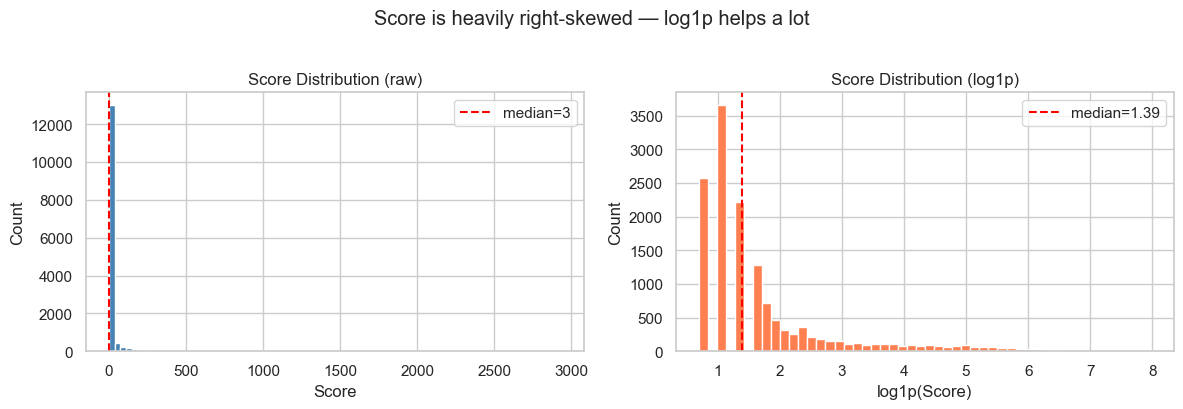

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# raw score -- clearly right skewed
axes[0].hist(df['score'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Score Distribution (raw)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
med = df['score'].median()
axes[0].axvline(med, color='red', linestyle='--', label=f'median={med:.0f}')
axes[0].legend()

# log1p transform makes it look much better
log_score = np.log1p(df['score'])
axes[1].hist(log_score, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Score Distribution (log1p)')
axes[1].set_xlabel('log1p(Score)')
axes[1].set_ylabel('Count')
axes[1].axvline(log_score.median(), color='red', linestyle='--',
                label=f'median={log_score.median():.2f}')
axes[1].legend()

plt.suptitle('Score is heavily right-skewed — log1p helps a lot', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# just double-checking the numbers
print(f'mean score: {df["score"].mean():.1f}')
print(f'median score: {df["score"].median():.1f}')
print(f'max score: {df["score"].max()}')
print(f'posts with score <= 5: {(df["score"] <= 5).sum()} ({(df["score"] <= 5).mean()*100:.1f}%)')

mean score: 21.2
median score: 3.0
max score: 2936
posts with score <= 5: 10436 (72.8%)


As expected, most posts barely get any upvotes. The mean is pulled up by a few viral posts. This confirms we should use `log1p(score)` as the prediction target.

### 1.2 Story Type Analysis

The dataset has 10 story types (external link, Show HN, GitHub, etc.). Let's see how many posts each type has and whether some types consistently score higher.

In [9]:
type_stats = df.groupby('story_type')['score'].agg(
    count='count',
    mean='mean',
    median='median'
).sort_values('mean', ascending=False)

type_stats

,count,mean,median
story_type,,,
other,42,30.761905,4.0
external,8475,25.599174,3.0
github,655,22.516031,2.0
news_major,1466,21.982265,5.0
research,450,18.186667,3.0
blog_personal,617,14.886548,3.0
ask_hn,346,12.742775,3.0
show_hn,1547,8.553975,2.0
video_media,478,6.500000,2.0


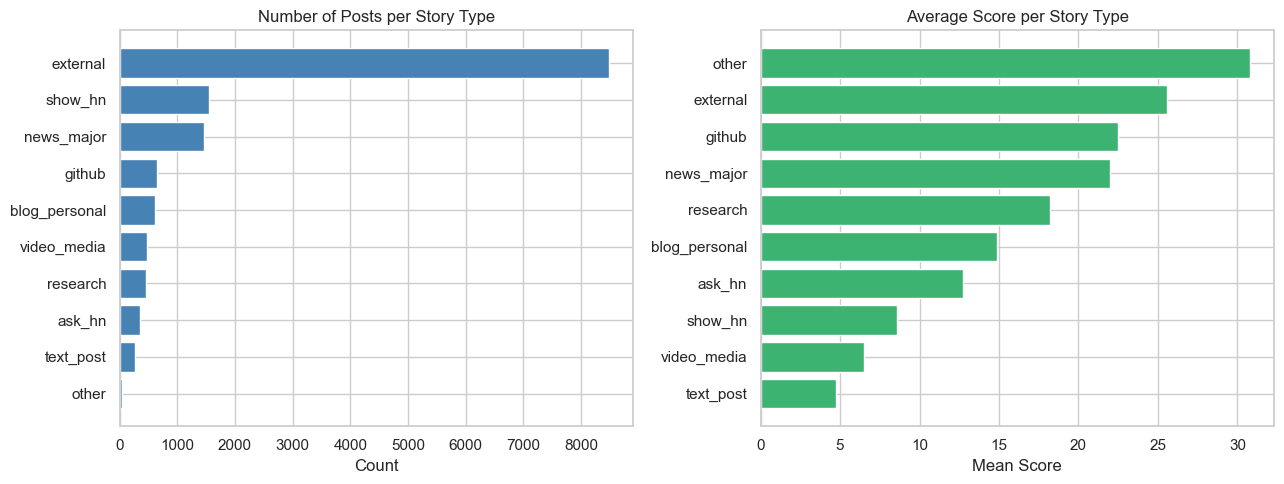

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# how many posts per type
count_order = type_stats.sort_values('count', ascending=True)
axes[0].barh(count_order.index, count_order['count'], color='steelblue')
axes[0].set_title('Number of Posts per Story Type')
axes[0].set_xlabel('Count')

# avg score per type -- sorted by mean
mean_order = type_stats.sort_values('mean', ascending=True)
axes[1].barh(mean_order.index, mean_order['mean'], color='mediumseagreen')
axes[1].set_title('Average Score per Story Type')
axes[1].set_xlabel('Mean Score')

plt.tight_layout()
plt.show()

Interesting — `external` is by far the most common type but not necessarily the highest scoring. Some niche types like `research` and `github` tend to get better scores relative to their volume. Story type will be an important feature for prediction.

### 1.3 Posting Time Patterns

Does it matter *when* you post? Let's look at hour of day and day of week — both for volume and for average score.

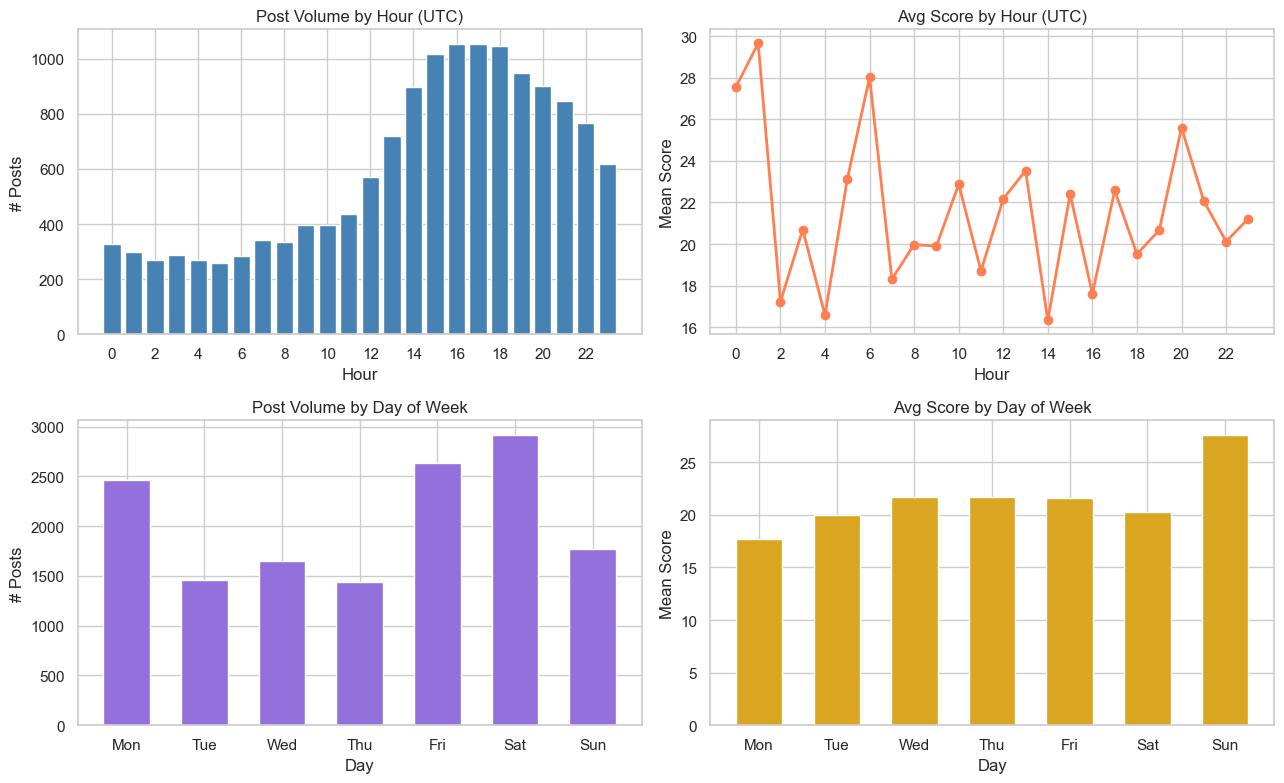

In [11]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- hour of day ---
hour_count = df.groupby('hour').size()
axes[0, 0].bar(hour_count.index, hour_count.values, color='steelblue', width=0.8)
axes[0, 0].set_title('Post Volume by Hour (UTC)')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('# Posts')
axes[0, 0].set_xticks(range(0, 24, 2))

hour_score = df.groupby('hour')['score'].mean()
axes[0, 1].plot(hour_score.index, hour_score.values, marker='o', color='coral', linewidth=2)
axes[0, 1].set_title('Avg Score by Hour (UTC)')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Mean Score')
axes[0, 1].set_xticks(range(0, 24, 2))

# --- day of week ---
day_count = df.groupby('day_of_week').size()
axes[1, 0].bar(day_count.index, day_count.values, color='mediumpurple', width=0.6)
axes[1, 0].set_title('Post Volume by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('# Posts')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(day_names)

day_score = df.groupby('day_of_week')['score'].mean()
axes[1, 1].bar(day_score.index, day_score.values, color='goldenrod', width=0.6)
axes[1, 1].set_title('Avg Score by Day of Week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Mean Score')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(day_names)

plt.tight_layout()
plt.show()

Weekdays clearly have more activity than weekends — makes sense since HN is mostly tech workers. The avg score by hour has some variation but it's a bit noisy. Still, `hour` and `day_of_week` seem worth keeping as features.

### 1.4 Title Length vs Score

Is there any relationship between how long a title is and how many upvotes it gets?

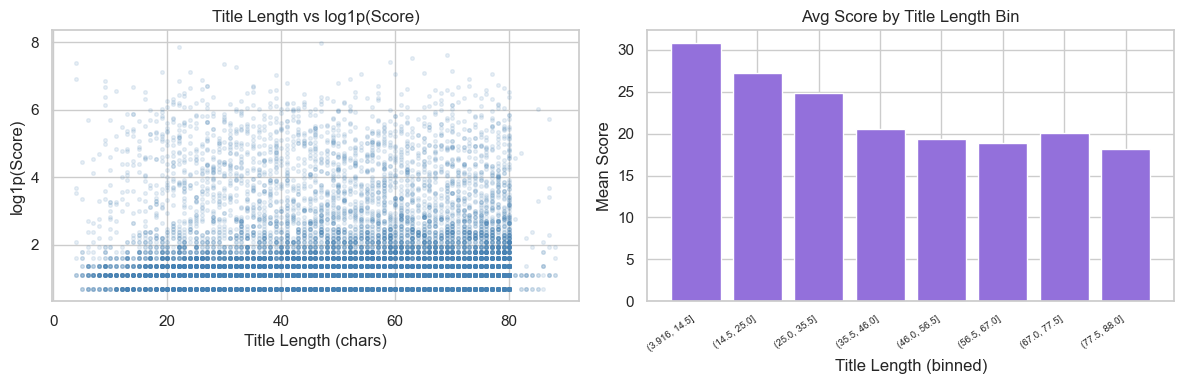

Pearson corr (title_length vs score): -0.0329


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# scatter plot -- log score to handle skew
axes[0].scatter(df['title_length'], np.log1p(df['score']),
                alpha=0.12, s=7, color='steelblue')
axes[0].set_title('Title Length vs log1p(Score)')
axes[0].set_xlabel('Title Length (chars)')
axes[0].set_ylabel('log1p(Score)')

# binned average -- cleaner way to see the trend
df['len_bin'] = pd.cut(df['title_length'], bins=8)
bin_score = df.groupby('len_bin', observed=True)['score'].mean()
axes[1].bar(range(len(bin_score)), bin_score.values, color='mediumpurple')
axes[1].set_title('Avg Score by Title Length Bin')
axes[1].set_xlabel('Title Length (binned)')
axes[1].set_ylabel('Mean Score')
axes[1].set_xticks(range(len(bin_score)))
axes[1].set_xticklabels(
    [str(b) for b in bin_score.index],
    rotation=35, ha='right', fontsize=7
)
df.drop(columns='len_bin', inplace=True)

plt.tight_layout()
plt.show()

print('Pearson corr (title_length vs score):', df['title_length'].corr(df['score']).round(4))

The correlation is pretty weak — title length alone doesn't tell you much. But we'll still keep it as a feature since it costs nothing and might help marginally.

---
## Section 2 — Text Preprocessing & TF-IDF

The title is the richest text feature we have. We'll clean it up and turn it into TF-IDF vectors, which will then be used for clustering. The steps are:
1. Lowercase everything
2. Strip punctuation and numbers
3. Remove English stopwords
4. Fit a TF-IDF vectorizer with max 500 features

In [13]:
stop_words = set(stopwords.words('english'))

def clean_title(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\d+', '', text)   # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['title_clean'] = df['title'].apply(clean_title)

# sanity check
df[['title', 'title_clean']].sample(5, random_state=42)

,title,title_clean
11355,Submission Deadline for 12th International Wor...,submission deadline th international workshop ...
3058,Glaphene: 2D hybrid material of graphene&silic...,glaphene hybrid material graphenesilica glass ...
11431,Show HN: Greens – mirror private GitHub activi...,show hn greens mirror private github activity ...
169,Trump and Starmer's White House talks: fact ch...,trump starmers white house talks fact checked
7953,Flux Playground,flux playground


In [14]:
# TF-IDF -- using unigrams + bigrams, min_df=3 to filter out very rare terms
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=3)
tfidf_matrix = tfidf.fit_transform(df['title_clean'])

print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('(rows = posts, cols = features)')

TF-IDF matrix shape: (14340, 500)
(rows = posts, cols = features)


---
## Section 3 — KMeans Clustering

Now we cluster the posts based on their TF-IDF title vectors. The idea is that posts talking about similar topics will end up in the same cluster, and cluster membership might help the model predict scores (e.g., certain topic clusters might consistently score higher).

We'll use the **elbow method** to decide on the number of clusters.

### 3.1 Elbow Method

Run KMeans for k=2 to 11 and plot the inertia. The "elbow" in the curve is where adding more clusters stops being worth it.

In [15]:
# normalize the matrix first -- helps KMeans with TF-IDF
X = normalize(tfidf_matrix)

k_range = range(2, 12)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f'k={k}  inertia={km.inertia_:.2f}')

k=2  inertia=11201.36
k=3  inertia=11061.60
k=4  inertia=10994.12
k=5  inertia=10981.22
k=6  inertia=10903.31
k=7  inertia=10780.62
k=8  inertia=10858.97
k=9  inertia=10834.34
k=10  inertia=10677.58
k=11  inertia=10628.29


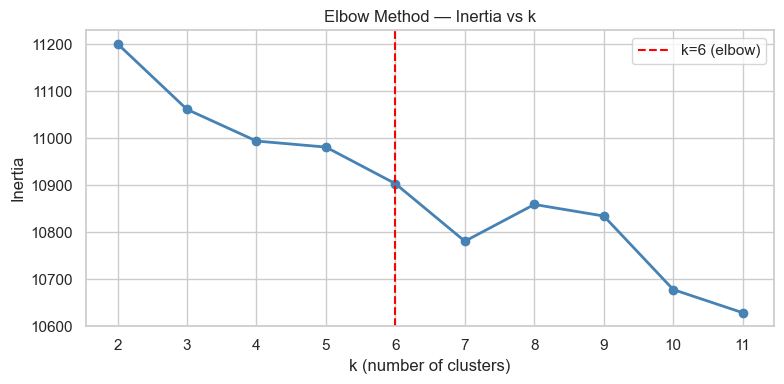

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
plt.axvline(x=6, color='red', linestyle='--', label='k=6 (elbow)')
plt.title('Elbow Method — Inertia vs k')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

The curve starts to flatten around k=6. Going higher doesn't reduce inertia much, so we'll go with **k=6**.

### 3.2 Fit Final Model (k=6)

In [17]:
k_best = 6

final_km = KMeans(n_clusters=k_best, random_state=42, n_init=20)
final_km.fit(X)

df['cluster'] = final_km.labels_

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    12063
1      351
2       99
3      107
4     1507
5      213
Name: count, dtype: int64


### 3.3 Top Terms per Cluster

What topics does each cluster represent? We look at which TF-IDF features have the highest weights in each cluster center.

In [18]:
feature_names = np.array(tfidf.get_feature_names_out())
centers = final_km.cluster_centers_

top_n = 10

print('Top terms per cluster:\n')
for i in range(k_best):
    top_idx = centers[i].argsort()[::-1][:top_n]
    terms = ', '.join(feature_names[top_idx])
    n_posts = (df['cluster'] == i).sum()
    print(f'Cluster {i} (n={n_posts}): {terms}')

Top terms per cluster:

Cluster 0 (n=12063): video, new, us, code, years, pdf, first, using, software, trump
Cluster 1 (n=351): ask, ask hn, hn, use, anyone, software, whats, would, get, using
Cluster 2 (n=99): without, show, show hn, hn, rust, app, pdf, web, linux, memory
Cluster 3 (n=107): go, show hn, show, hn, written, rust, python, must, deep, library
Cluster 4 (n=1507): show, show hn, hn, built, tool, hn built, app, opensource, game, made
Cluster 5 (n=213): data, using, privacy, storage, google, scale, science, firefox, new, secure


### 3.4 Score Distribution Across Clusters

Do some clusters have higher scores on average? If yes, cluster membership is a useful feature for prediction.

In [19]:
print('Mean / Median score per cluster:')
df.groupby('cluster')['score'].agg(['mean', 'median', 'count']).round(1)

Mean / Median score per cluster:


,mean,median,count
cluster,,,
0,22.8,3.0,12063
1,12.6,3.0,351
2,25.2,3.0,99
3,22.5,3.0,107
4,8.7,2.0,1507
5,31.0,2.0,213


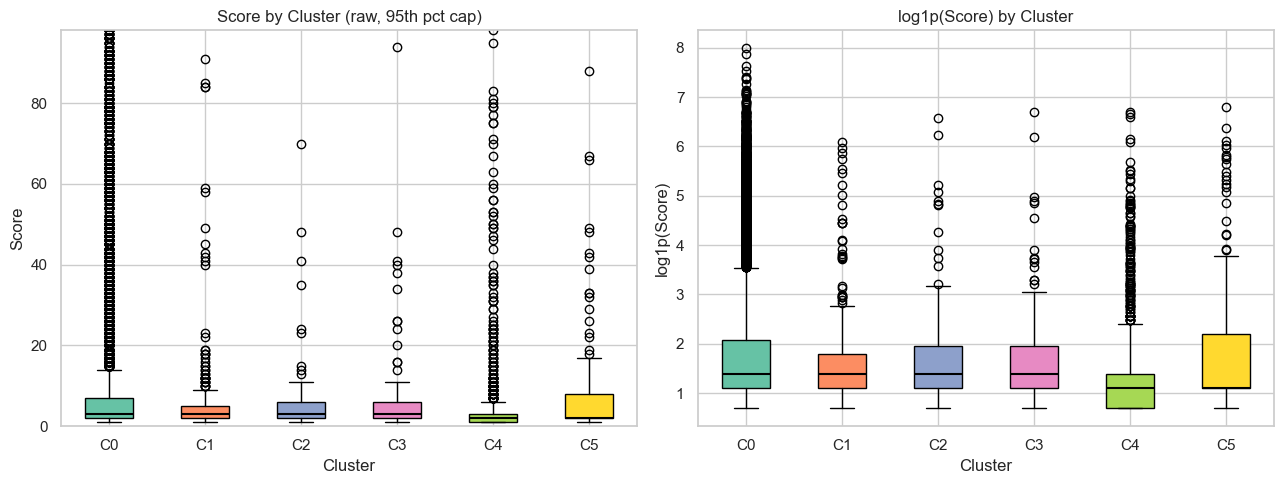

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cluster_groups = [df.loc[df['cluster'] == c, 'score'].values for c in range(k_best)]
log_groups = [np.log1p(g) for g in cluster_groups]

# raw score boxplot (cap outliers for readability)
bp1 = axes[0].boxplot(cluster_groups, patch_artist=True,
                      medianprops=dict(color='black', linewidth=1.5))
colors = sns.color_palette('Set2', k_best)
for patch, c in zip(bp1['boxes'], colors):
    patch.set_facecolor(c)
axes[0].set_ylim(0, df['score'].quantile(0.95))
axes[0].set_title('Score by Cluster (raw, 95th pct cap)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels([f'C{i}' for i in range(k_best)])

# log score boxplot
bp2 = axes[1].boxplot(log_groups, patch_artist=True,
                      medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c)
axes[1].set_title('log1p(Score) by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('log1p(Score)')
axes[1].set_xticklabels([f'C{i}' for i in range(k_best)])

plt.tight_layout()
plt.show()

### 3.5 Cluster × Story Type

Quick sanity check — do the clusters align with story types at all? If clusters are totally random w.r.t. story type, that might mean the text clustering isn't capturing meaningful structure.

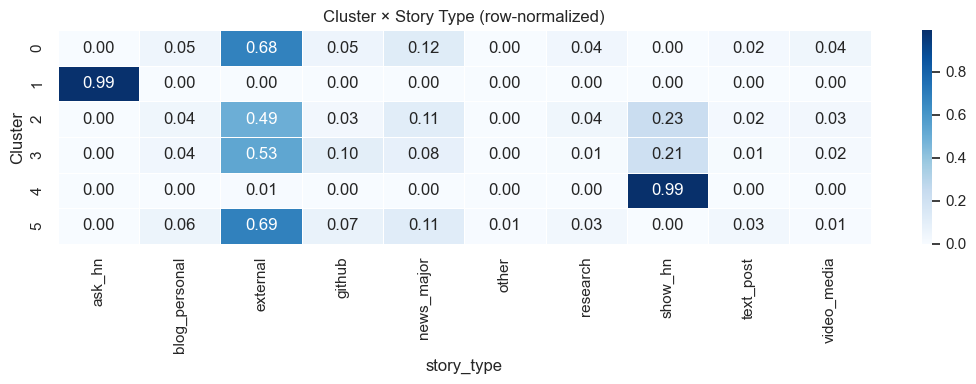

In [21]:
ct = pd.crosstab(df['cluster'], df['story_type'], normalize='index').round(3)

plt.figure(figsize=(11, 4))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Cluster × Story Type (row-normalized)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

There's some structure — clusters don't have uniform story type distributions. This suggests the text clusters do capture something meaningful about the posts.

---
## Section 4 — Export

Save the dataframe with the new `cluster` column. This file will be the input for the prediction notebook.

Notes:
- Dropping `title_clean` (temporary helper column, not needed downstream)
- Keeping all original columns intact
- NOT including `num_comments` as a feature — that's data leakage
- NOT including `summary` — it's mostly empty anyway

In [22]:
# drop the helper column we added for cleaning
df_out = df.drop(columns=['title_clean'])

output_path = 'data/hn_with_clusters.csv'
df_out.to_csv(output_path, index=False)

print(f'Saved to {output_path}')
print(f'Shape: {df_out.shape}')
print(f'Columns: {list(df_out.columns)}')

Saved to data/hn_with_clusters.csv
Shape: (14340, 21)
Columns: ['objectID', 'title', 'url', 'author', 'score', 'num_comments', 'summary', 'summary_source', 'summary_length', 'created_at', 'date', 'year_month', 'day_of_week', 'hour', 'is_weekend', 'title_length', 'title_word_count', 'has_url', 'has_text', 'story_type', 'cluster']


In [23]:
# quick verification
check = pd.read_csv(output_path)
print('cluster value counts in saved file:')
print(check['cluster'].value_counts().sort_index())

cluster value counts in saved file:
cluster
0    12063
1      351
2       99
3      107
4     1507
5      213
Name: count, dtype: int64


---
## Summary

**EDA takeaways:**
- Score is very right-skewed (median=3, some posts > 2000). Log transform is necessary.
- Story type matters — research/github posts tend to score higher despite lower volume.
- Weekday mornings (UTC) have more activity. Score variance by hour/day exists but is noisy.
- Title length has weak correlation with score on its own.

**Clustering:**
- Used TF-IDF (500 features, unigrams+bigrams) on cleaned titles.
- Elbow method suggested k=6. Clusters show distinct topic themes and some variation in average score.
- `cluster` added to dataset → `data/hn_with_clusters.csv` ready for prediction notebook.